# Car Price Analysis Project

## 1.Importing Libraries 

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import confusion_matrix

from sklearn.model_selection import train_test_split

## 2.Reading Data Set 

In [6]:
df = pd.read_csv("car_price.csv")
print(f'Shape: {df.shape}')
df.head()

Shape: (72435, 10)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


## 3.Exploratory Data Analysis 'EDA'

df.info()

In [7]:
df.columns = ['Model', 'Year', 'Price','Transmission','Mileage','Fuel Type','Tax','MPG','Engine Size','Brand']
df.columns.tolist()

['Model',
 'Year',
 'Price',
 'Transmission',
 'Mileage',
 'Fuel Type',
 'Tax',
 'MPG',
 'Engine Size',
 'Brand']

In [8]:
df.isnull().sum()

Model           3621
Year            3622
Price           3621
Transmission    3623
Mileage         3622
Fuel Type       3622
Tax             3621
MPG             3621
Engine Size     3622
Brand           3621
dtype: int64

In [9]:
df['Brand'].value_counts()

Brand
Ford       17045
vw         14393
BMW        10269
audi       10137
toyota      6417
skoda       5947
Hyundai     4606
Name: count, dtype: int64

In [10]:
df['Fuel Type'].value_counts()

Fuel Type
Petrol      38390
Diesel      27446
Hybrid       2747
Other         225
Electric        5
Name: count, dtype: int64

In [11]:
df['Transmission'].value_counts()

Transmission
Manual       40839
Semi-Auto    14611
Automatic    13358
Other            4
Name: count, dtype: int64

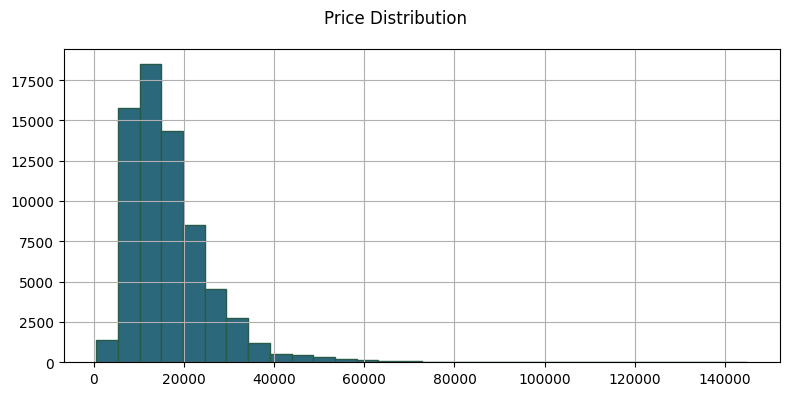

In [12]:
df['Price'].hist(figsize=(8, 4), bins=30, edgecolor='#285A48', color='#2C687B')
plt.suptitle('Price Distribution')
plt.tight_layout()
plt.show()

In [13]:
df.describe()

,Year,Price,Mileage,Tax,MPG,Engine Size
count,68813.000000,68814.000000,68813.000000,68814.000000,68814.000000,68813.000000
mean,2017.077660,16583.919261,23179.439539,116.930421,55.836352,1.635373
std,2.099474,9304.412707,21347.569657,64.081931,17.043643,0.561734
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10167.250000,7199.000000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17521.000000,145.000000,55.400000,1.600000
75%,2019.000000,20359.750000,32478.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


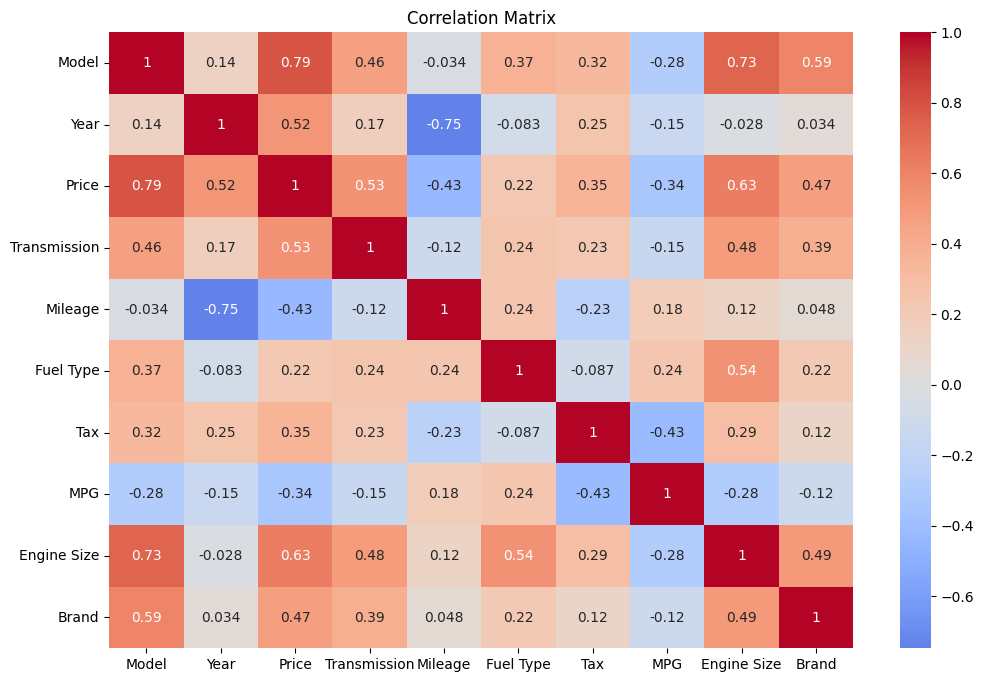

In [14]:
df_copy = df.copy()
df_copy['Brand'] = df_copy.groupby('Brand')['Price'].transform('mean')
df_copy['Model'] = df_copy.groupby('Model')['Price'].transform('mean')
df_copy['Fuel Type'] = df_copy.groupby('Fuel Type')['Price'].transform('mean')
df_copy['Transmission'] = df_copy.groupby('Transmission')['Price'].transform('mean')

corr_matrix = df_copy.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,annot=True)
plt.title("Correlation Matrix")
plt.show()


## 4.Data Preprocessing

### 1.Handling Missing Values

In [15]:
# We only drop rows with missing value in the target column (the price)***
df = df.dropna(subset=['Price'])

In [16]:
# *Splitting the data before cleaning to prevent data leakage

X = df.drop('Price',axis=1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

## Missing Values for Numerical Data

In [17]:
# Handling missing values for numeric features Using the median (Robust against outliers), since only around 5% of each column is missing, we are not going to drop them

numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
numeric_imputer = SimpleImputer(strategy="median")
X_train[numeric_cols] = numeric_imputer.fit_transform(X_train[numeric_cols])

# Fitting only on Training data and trasforiming both to prevent data leakage

X_test[numeric_cols] = numeric_imputer.transform(X_test[numeric_cols])

## Missing Values for Categorical Data
using multi-level conditional imputation is better than a generic most-frequent fill to preserve the logical relationships between variables and maintain the statistical distribution of the dataset. 

In [18]:
impute_map = {
    'Model':        'Brand',
    'Brand':         'Model',
    'Fuel Type':     'Model',
    'Transmission': 'Model'
}

for target, ref in impute_map.items():
    global_mode = X_train[target].mode()[0]
    
    train_rules = X_train.groupby(ref)[target].agg(
        lambda x: x.mode()[0] if not x.mode().empty else global_mode
    )
    
    X_train[target] = X_train[target].fillna(X_train[ref].map(train_rules))
    X_train[target] = X_train[target].fillna(global_mode)
    
    X_test[target] = X_test[target].fillna(X_test[ref].map(train_rules))
    X_test[target] = X_test[target].fillna(global_mode)

In [19]:
# Checking for any missing values
X_train.isnull().sum().sum() + X_test.isnull().sum().sum()

np.int64(0)

In [20]:
y_train.isnull().sum().sum() + y_test.isnull().sum().sum()

np.int64(0)

# Outliers Detection and Handling Using the IQR Method

In [21]:
# Clipping Values out of IQR Bounds
numeric_features = X_train.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_features:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    X_train[col] = X_train[col].clip(lower=lower, upper=upper)
    X_test[col] = X_test[col].clip(lower=lower, upper=upper)

In [22]:
# Using data from the training set to prevent data leakage
Q1_y = y_train.quantile(0.25)
Q3_y = y_train.quantile(0.75)
IQR_y = Q3_y - Q1_y

lower_y = Q1_y - 1.5 * IQR_y
upper_y = Q3_y + 1.5 * IQR_y

y_train = y_train.clip(lower=lower_y, upper=upper_y)
y_test = y_test.clip(lower=lower_y, upper=upper_y)

# Scaling Numerical Features Using the StandardScaler

In [23]:
numeric_cols_to_scale = ['Year', 'Mileage', 'Tax', 'MPG', 'Engine Size']

scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train[numeric_cols_to_scale])
X_test_num_scaled  = scaler.transform(X_test[numeric_cols_to_scale])

X_train_num_scaled = pd.DataFrame(X_train_num_scaled, columns=numeric_cols_to_scale, index=X_train.index)
X_test_num_scaled  = pd.DataFrame(X_test_num_scaled,  columns=numeric_cols_to_scale, index=X_test.index)


# Encoding
Using One-Hot Encoding because there is no ordinal relationship between columns

In [24]:
cat_cols = ['Model','Transmission', 'Fuel Type', 'Brand']

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_enc = enc.fit_transform(X_train[cat_cols])
X_test_enc = enc.transform(X_test[cat_cols])

encoded_cols = enc.get_feature_names_out(cat_cols)

X_train_ohe = pd.DataFrame(X_train_enc, columns=encoded_cols, index=X_train.index)
X_test_ohe = pd.DataFrame(X_test_enc, columns=encoded_cols, index=X_test.index)

In [25]:
X_train_final = X_train_num_scaled.join(X_train_ohe)
X_test_final  = X_test_num_scaled.join(X_test_ohe)

# Linear Regression

Simple Linear Regression: (one feature)

In [41]:
# Finding the feature with strongest correlation with Price 
correlation_matrix = pd.concat([X_train_final, y_train], axis=1).corr()

top_feature = correlation_matrix['Price'].drop('Price').abs().idxmax()
print(f"The feature with the strongest correlation to Price is: {top_feature}")

The feature with the strongest correlation to Price is: Engine Size


In [42]:
simple_model = LinearRegression()
# Train Model 
simple_model.fit(X_train_final[[top_feature]], y_train)

# Predict Training Data
simple_y_train_pred = simple_model.predict(X_train_final[[top_feature]])

# Predict Test Data 
simple_y_test_pred = simple_model.predict(X_test_final[[top_feature]])

# Compute RMSE for both Train and Test
simple_train_rmse = np.sqrt(mean_squared_error(y_train, simple_y_train_pred))
simple_test_rmse = np.sqrt(mean_squared_error(y_test, simple_y_test_pred))

print("Simple Linear Regression:")
print("Train RMSE:", simple_train_rmse)
print("Test RMSE:", simple_test_rmse)

# Equation
simple_coef = simple_model.coef_[0]
simple_intercept = simple_model.intercept_

print(f"Y = {simple_coef:.2f}X + {simple_intercept:.2f}")

Simple Linear Regression:
Train RMSE: 6244.945162642882
Test RMSE: 6265.08194027827
Y = 4621.24X + 16155.72


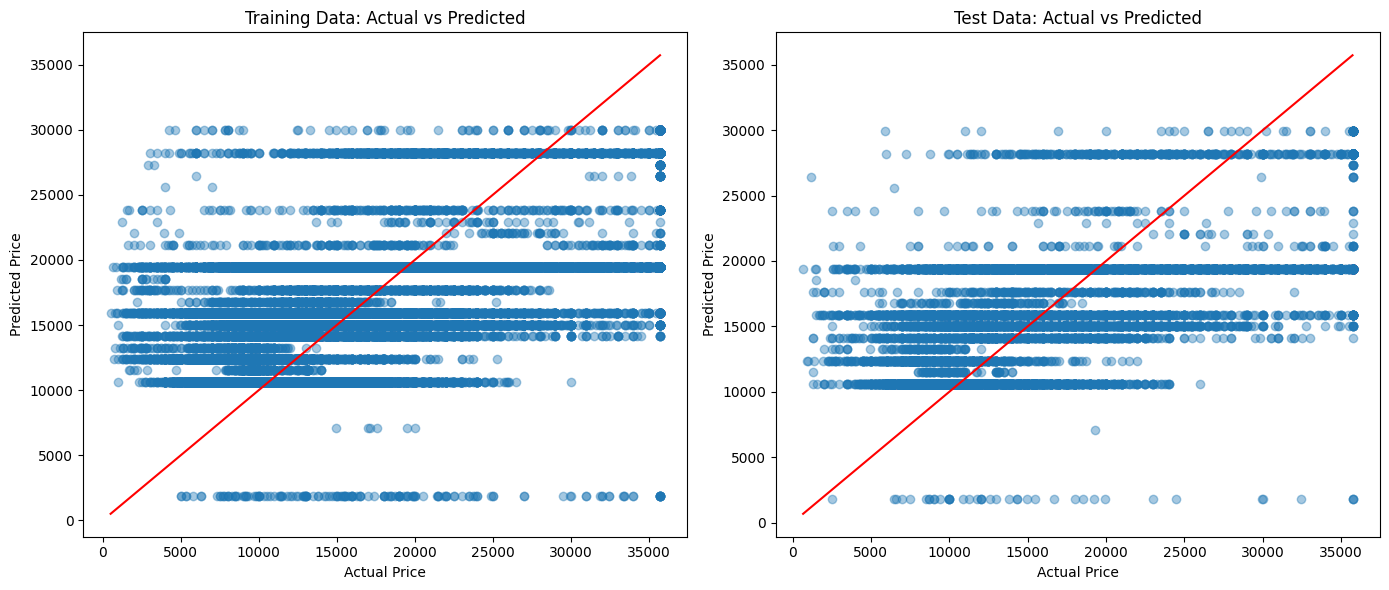

In [28]:
# side by side plots for training data and testing data using the simple regression model

plt.figure(figsize=(14,6))

# Train
plt.subplot(1,2,1)
plt.scatter(y_train, simple_y_train_pred, alpha=0.4)

min_val = min(y_train.min(), simple_y_train_pred.min())
max_val = max(y_train.max(), simple_y_train_pred.max())

x_line = np.linspace(min_val, max_val, 100)
y_line = x_line

plt.plot(x_line, y_line, color='red')

plt.title("Training Data: Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

# Test
plt.subplot(1,2,2)
plt.scatter(y_test, simple_y_test_pred, alpha=0.4)

min_val = min(y_test.min(), simple_y_test_pred.min())
max_val = max(y_test.max(), simple_y_test_pred.max())

x_line = np.linspace(min_val, max_val, 100)
y_line = x_line

plt.plot(x_line, y_line, color='red')

plt.title("Test Data: Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.tight_layout()
plt.show()

Model Evaluation
1. Root Mean Squared Error (RMSE): measures the average prediction error in the same units as the target variable (car price).
2. R² Score: measures how well the model explains the variation in car prices.

In [29]:
print("Simple Linear Regression Evaluation:")
print("Test RMSE:", simple_test_rmse)
simple_r2 = r2_score(y_test, simple_y_test_pred)
print("Test R²:", simple_r2)

Simple Linear Regression Evaluation:
Test RMSE: 6265.08194027827
Test R²: 0.35693497570517263


Multiple Linear Regression: (all features)

In [31]:
# Multiple Linear Regression Model
multi_model = LinearRegression()

# Train Model (ALL features)
multi_model.fit(X_train_final, y_train)

# Predict Training Data
multi_y_train_pred = multi_model.predict(X_train_final)

# Predict Test Data
multi_y_test_pred = multi_model.predict(X_test_final)

# Compute RMSE for both Train and Test
multi_train_rmse= np.sqrt(mean_squared_error(y_train, multi_y_train_pred))
multi_test_rmse = np.sqrt(mean_squared_error(y_test, multi_y_test_pred))

print("Multiple Regression Model:")
print("Train RMSE:", multi_train_rmse)
print("Test RMSE:", multi_test_rmse)


Multiple Regression Model:
Train RMSE: 2572.507106179544
Test RMSE: 2601.1497525486047


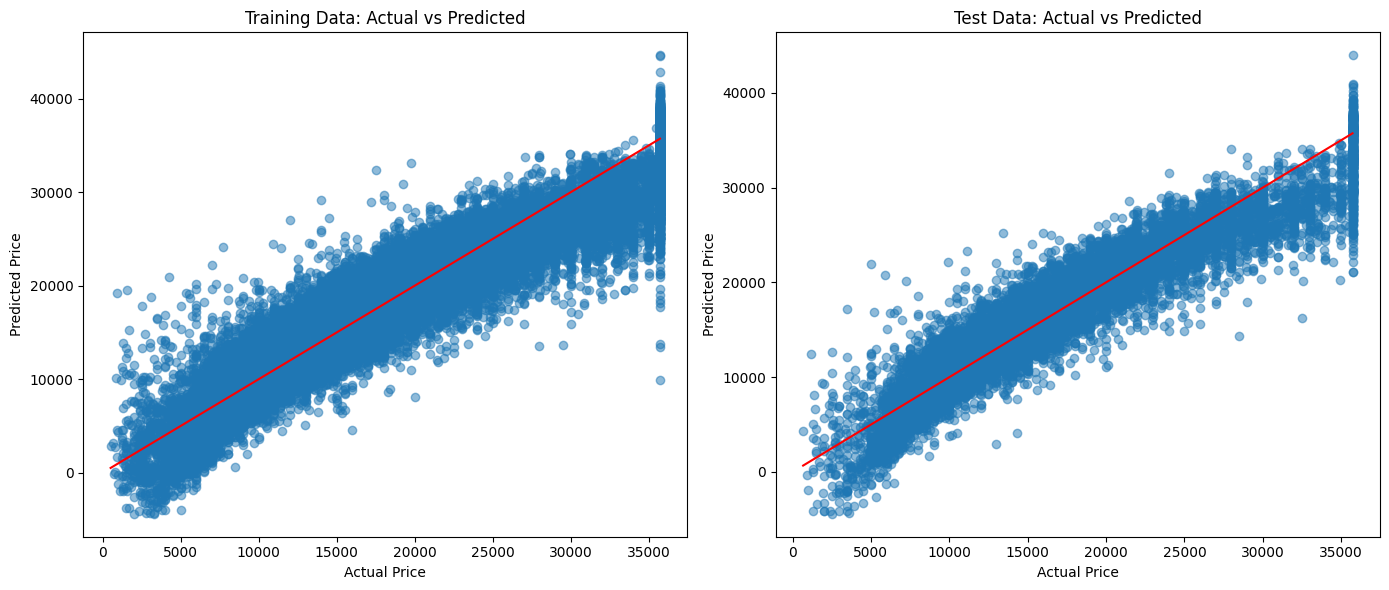

Y = (2645.40 × Year) + (-1699.01 × Mileage) + (-461.23 × Tax) + (-1425.53 × MPG) + (1680.04 × Engine Size) + (-5600.47 × Model_ 1 Series) + (-5214.17 × Model_ 2 Series) + (-3623.84 × Model_ 3 Series) + (-2943.00 × Model_ 4 Series) + (-1675.27 × Model_ 5 Series) + (-1731.92 × Model_ 6 Series) + (1682.90 × Model_ 7 Series) + (1755.63 × Model_ 8 Series) + (-6224.22 × Model_ A1) + (-6143.01 × Model_ A2) + (-4207.51 × Model_ A3) + (-3853.89 × Model_ A4) + (-1897.73 × Model_ A5) + (-2251.54 × Model_ A6) + (-931.74 × Model_ A7) + (909.96 × Model_ A8) + (-2814.25 × Model_ Accent) + (3150.71 × Model_ Amarok) + (5.40 × Model_ Amica) + (2472.81 × Model_ Arteon) + (-3444.61 × Model_ Auris) + (-2469.80 × Model_ Avensis) + (-5013.23 × Model_ Aygo) + (-2961.34 × Model_ B-MAX) + (-2719.89 × Model_ Beetle) + (427.00 × Model_ C-HR) + (-2289.00 × Model_ C-MAX) + (-2551.64 × Model_ CC) + (160.41 × Model_ Caddy) + (-1886.65 × Model_ Caddy Life) + (-4743.25 × Model_ Caddy Maxi) + (-3573.15 × Model_ Caddy Ma

In [32]:
# side by side plots for training data and testing data using the multiple regression model

# Equation
features = X_train_final.columns
coefs = multi_model.coef_
intercept = multi_model.intercept_

equation = "Y = " + " + ".join(
    [f"({coef:.2f} × {feat})" for coef, feat in zip(coefs, features)]) + f" + ({intercept:.2f})"

plt.figure(figsize=(14,6))

# Train
plt.subplot(1,2,1)
plt.scatter(y_train, multi_y_train_pred, alpha=0.5)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='red')

plt.title("Training Data: Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

# Test
plt.subplot(1,2,2)
plt.scatter(y_test, multi_y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.title("Test Data: Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.tight_layout()
plt.show()

print(equation)

Model Evaluation
1. Root Mean Squared Error (RMSE): measures the average prediction error in the same units as the target variable (car price).
2. R² Score: measures how well the model explains the variation in car prices.

In [33]:
print("Multiple Linear Regression Evaluation:")
print("Test RMSE:", multi_test_rmse)
multi_r2 = r2_score(y_test, multi_y_test_pred)
print("Test R²:", multi_r2)

Multiple Linear Regression Evaluation:
Test RMSE: 2601.1497525486047
Test R²: 0.8891509206656975


# Classification

In [34]:
# Dimension reduction using PCA to prepare for the KNN model
from sklearn.decomposition import PCA

# Choose enough components to keep 95% of the variance
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_final)
X_test_pca = pca.transform(X_test_final)

print(f"New number of dimensions: {X_train_pca.shape[1]}")

New number of dimensions: 28


In [35]:
# Creating 3 categories: Low, Medium and High price
y_train_cat = pd.qcut(y_train, q=3, labels=["Low", "Medium", "High"])
y_test_cat = pd.qcut(y_test, q=3, labels=["Low", "Medium", "High"])

In [36]:
from sklearn.preprocessing import LabelEncoder

# Encoding the data to solve the problem with the manhattan distance (the warning)
le = LabelEncoder()

# Converting Low, Medium and High to 0, 1 and 2
y_train_encoded = le.fit_transform(y_train_cat)
y_test_encoded = le.transform(y_test_cat)

In [48]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', verbose=1,n_jobs=-1)

grid_search.fit(X_train_pca, y_train_encoded)

print(f"Best Parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 5}


In [38]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_pca)


print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91      4581
           1       0.90      0.90      0.90      4601
           2       0.81      0.81      0.81      4581

    accuracy                           0.87     13763
   macro avg       0.87      0.87      0.87     13763
weighted avg       0.87      0.87      0.87     13763



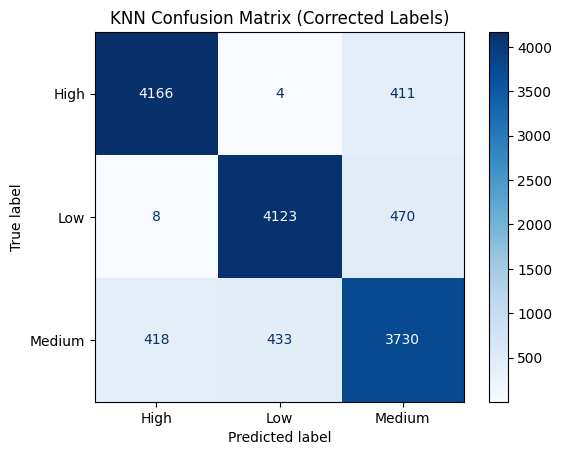

In [39]:
cm = confusion_matrix(y_test_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("KNN Confusion Matrix (Corrected Labels)")
plt.show()

# Code Analysis and Discussion 

## 6.1 Model Comparison

### Question 1:
Which model performed better, and what does better mean in each context?
### Answer 1:
The 2 models are trying to solve 2 different problems. However, I'd say that the linear regression model is more suitable for this dataset since we would likely want to predict the price of a car based on the given features.

As for the second part of the question:
For Linear Regression, better means lower RMSE and higher R². these indicate how close the predicted prices were to the actual prices
For KNN Classification, better means higher Accuracy, Precision, Recall, and F1. These matrices tell us that, on average, how correctly did the KNN model assign a car to the right category (low, medium or high)

### Question 2:
Is classification easier than regression on this dataset? Why or why not?
### Answer 2:
Classification is easier since it is easier to predict the right category or price range than to predict the exact price.

### Question 3:
Does converting price into categories lose important information?
### Answer 3:
Yes. because for example, two cars with the prices of 11,999 and 25,000 would be treated as the same category "medium".

## 6.2 Sensitivity Analysis

### Question 1:
What happens if you remove the most correlated feature? Does performance drop a lot?

In [46]:
# We already know from simple linear regreession that the most correlated featuer is Engine Size
print(f"Most correlated feature: {top_feature}")

X_train_dropped = X_train_final.drop(columns=[top_feature])
X_test_dropped  = X_test_final.drop(columns=[top_feature])

model_dropped = LinearRegression()
model_dropped.fit(X_train_dropped, y_train)
y_pred_dropped = model_dropped.predict(X_test_dropped)

rmse_dropped = np.sqrt(mean_squared_error(y_test, y_pred_dropped))
r2_dropped   = r2_score(y_test, y_pred_dropped)

print(f"\nWith all features: RMSE: {multi_test_rmse:.2f} | R²: {multi_r2:.4f}")
print(f"Without Engine Size: RMSE: {rmse_dropped:.2f} | R²: {r2_dropped:.4f}")

Most correlated feature: Engine Size

With all features: RMSE: 2601.15 | R²: 0.8892
Without Engine Size: RMSE: 2739.31 | R²: 0.8771


In [51]:
pca_dropped = PCA(n_components=0.95)
X_train_dropped_pca = pca_dropped.fit_transform(X_train_dropped)
X_test_dropped_pca  = pca_dropped.transform(X_test_dropped)

# Using the same best parameters found by GridSearch
knn_dropped = KNeighborsClassifier(
    n_neighbors=grid_search.best_params_['n_neighbors'],
    metric=grid_search.best_params_['metric']
)

knn_dropped.fit(X_train_dropped_pca, y_train_encoded)
y_pred_dropped_knn = knn_dropped.predict(X_test_dropped_pca)

acc_full    = accuracy_score(y_test_encoded, y_pred)
acc_dropped = accuracy_score(y_test_encoded, y_pred_dropped_knn)

print(f"KNN Accuracy with Engine Size {acc_full:.4f}")
print(f"KNN Accuracy Without Engine Size {acc_dropped:.4f}")
print(f"Accuracy drop: +{acc_full - acc_dropped:.4f}")

KNN Accuracy with Engine Size 0.8733
KNN Accuracy Without Engine Size 0.8681
Accuracy drop: +0.0052


### Answer 1:
Only around a 138 increase in RMSE, a .0121 decrease in R2 for MLR models, and around a 0.52% drop in accuracy for KNN so no, the performance did not drop a lot. This is generally a good sign and means that the model has learned genuine patterns across the data and that the other features compensate well.  

### Question 2:
Try running KNN without scaling — how much does performance change?

In [54]:
# Unscaled Data
X_train_num_raw = X_train[numeric_cols_to_scale] 
X_test_num_raw  = X_test[numeric_cols_to_scale]

X_train_num_raw.describe()

,Year,Mileage,Tax,MPG,Engine Size
count,55051.000000,55051.000000,55051.000000,55051.000000,55051.000000
mean,2017.120461,22048.577973,134.069862,55.206493,1.628659
std,1.842245,18029.338655,23.633651,11.226016,0.525855
min,2011.500000,1.000000,95.000000,25.550000,0.000000
25%,2016.000000,7676.500000,125.000000,47.900000,1.200000
50%,2017.000000,17516.000000,145.000000,55.400000,1.600000
75%,2019.000000,31553.500000,145.000000,62.800000,2.000000
max,2020.000000,67369.000000,175.000000,85.150000,3.200000


In [57]:
X_train_final_unscaled = X_train_num_raw.join(X_train_ohe)
X_test_final_unscaled  = X_test_num_raw.join(X_test_ohe)

pca_unscaled = PCA(n_components=0.95)
X_train_unscaled_pca = pca_unscaled.fit_transform(X_train_final_unscaled)
X_test_unscaled_pca  = pca_unscaled.transform(X_test_final_unscaled)

knn_no_scale = KNeighborsClassifier(
    n_neighbors=grid_search.best_params_['n_neighbors'],
    metric=grid_search.best_params_['metric']
)

knn_no_scale.fit(X_train_unscaled_pca, y_train_encoded)
y_pred_no_scale = knn_no_scale.predict(X_test_unscaled_pca)
acc_no_scaling = accuracy_score(y_test_encoded, y_pred_no_scale)

print(f"KNN Accuracy With scaling :{acc_full:.4f}")
print(f"KNN Accuracy Without scaling: {acc_no_scaling:.4f}")

KNN Accuracy With scaling :0.8733
KNN Accuracy Without scaling: 0.4802


### Answer 2:
Yes, we notice a 39.31% decrease in accuracy in the KNN model without scaling the data. This is because that KNN is a distance-based algorithm and scaling is necessary to ensure that features such as Mileage (ranges 0–150,000) wouldn't completely dominate other features with a small range such as Engine Size (only ranges 1–5)

### Question 3:
Try a different threshold for your price categories — does KNN accuracy change
significantly?

### Answer 3 Part 1:
Instead of using 3 equal 33% quantiles, we will shift the thresholds to make the medium category much wider with only 15% for low and high categories and 70% being moderate

In [59]:
new_quantiles = y_train.quantile([0.15, 0.85])
low_thresh = new_quantiles[0.15]
high_thresh = new_quantiles[0.85]

def shifted_categorize(price):
    if price < low_thresh:
        return 'Cheap'
    elif price < high_thresh:
        return 'Moderate'
    else:
        return 'Expensive'

y_train_shifted = y_train.apply(shifted_categorize)
y_test_shifted = y_test.apply(shifted_categorize)

le_diff_cats = LabelEncoder()

y_train_shifted = le_diff_cats.fit_transform(y_train_shifted)
y_test_shifted = le_diff_cats.transform(y_test_shifted)

knn_diff_cats = KNeighborsClassifier(
    n_neighbors=grid_search.best_params_['n_neighbors'],
    metric=grid_search.best_params_['metric']
)

knn_diff_cats.fit(X_train_pca, y_train_shifted)
y_pred_shifted = knn_diff_cats.predict(X_test_pca)
acc_diff_cats = accuracy_score(y_test_shifted, y_pred_shifted)

print(f"Original Accuracy (33/33/33): {acc_full:.4f}")
print(f"Shifted Accuracy (15/70/15): {acc_diff_cats:.4f}")

Original Accuracy (33/33/33): 0.8733
Shifted Accuracy (15/70/15): 0.9096


In [60]:
print(classification_report(y_test_shifted, y_pred_shifted))

              precision    recall  f1-score   support

           0       0.85      0.80      0.83      2059
           1       0.88      0.85      0.87      2100
           2       0.93      0.95      0.94      9604

    accuracy                           0.91     13763
   macro avg       0.89      0.87      0.88     13763
weighted avg       0.91      0.91      0.91     13763



In [61]:
print(dict(zip(le_diff_cats.classes_, le_diff_cats.transform(le_diff_cats.classes_))))

{'Cheap': np.int64(0), 'Expensive': np.int64(1), 'Moderate': np.int64(2)}


### Answer 3 Part 2:
While the overall accuracy increased to 91%, we noticed a significant decrease in precision, recall and f1-score in each of the cheap and expensive categories, which tells us that the ability of the model to classify cars in these categories decreased. This shows that accuracy alone can be a misleading metric when class sizes are unbalanced.

# Required Visualizations

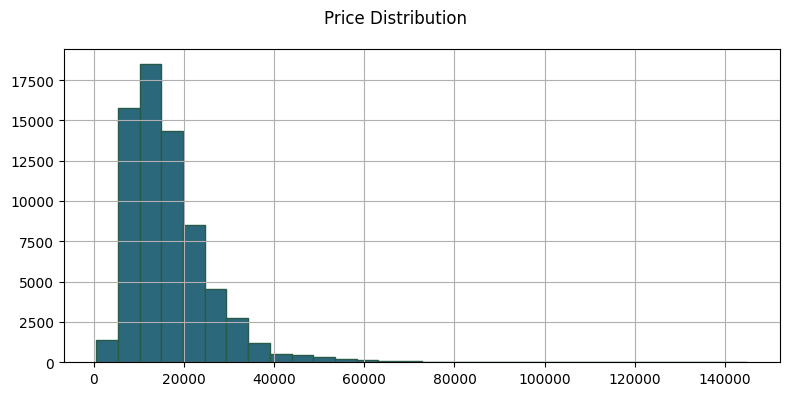

In [62]:
df['Price'].hist(figsize=(8, 4), bins=30, edgecolor='#285A48', color='#2C687B')
plt.suptitle('Price Distribution')
plt.tight_layout()
plt.show()

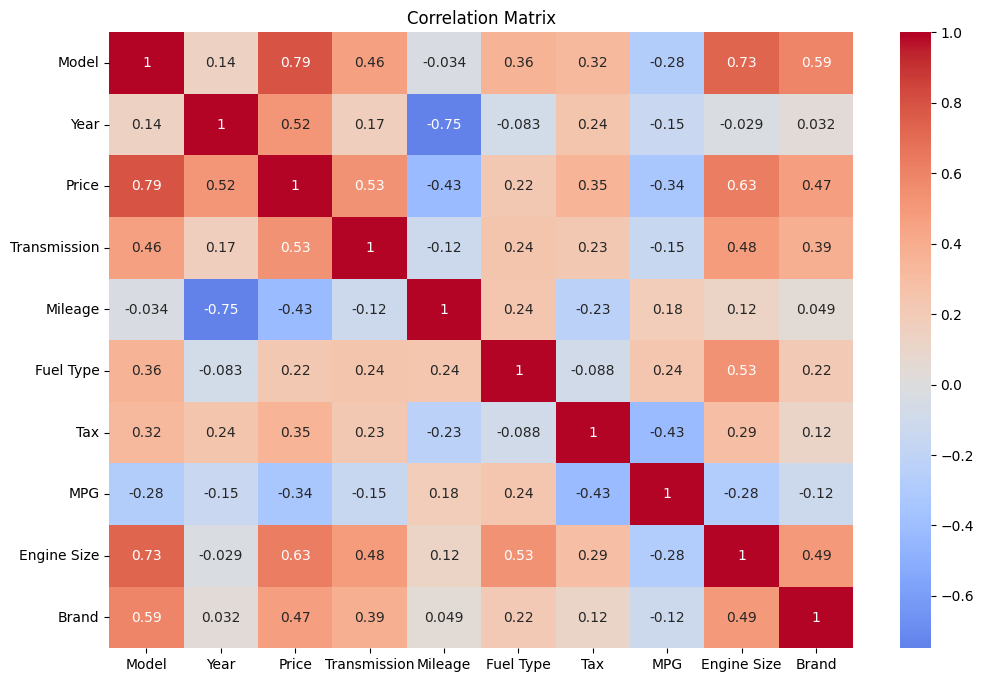

In [63]:
df_copy = df.copy()
df_copy['Brand'] = df_copy.groupby('Brand')['Price'].transform('mean')
df_copy['Model'] = df_copy.groupby('Model')['Price'].transform('mean')
df_copy['Fuel Type'] = df_copy.groupby('Fuel Type')['Price'].transform('mean')
df_copy['Transmission'] = df_copy.groupby('Transmission')['Price'].transform('mean')

corr_matrix = df_copy.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,annot=True)
plt.title("Correlation Matrix")
plt.show()


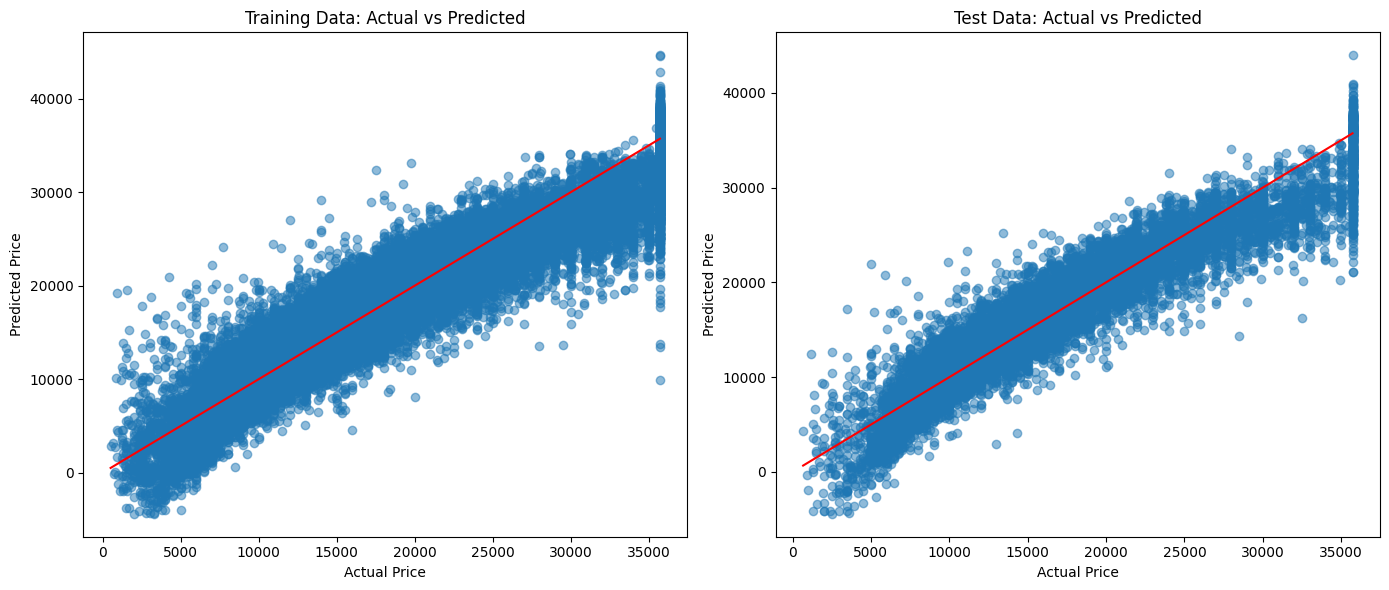

In [65]:
# side by side plots for training data and testing data using the multiple regression model

# Equation
features = X_train_final.columns
coefs = multi_model.coef_
intercept = multi_model.intercept_

equation = "Y = " + " + ".join(
    [f"({coef:.2f} × {feat})" for coef, feat in zip(coefs, features)]) + f" + ({intercept:.2f})"

plt.figure(figsize=(14,6))

# Train
plt.subplot(1,2,1)
plt.scatter(y_train, multi_y_train_pred, alpha=0.5)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='red')

plt.title("Training Data: Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

# Test
plt.subplot(1,2,2)
plt.scatter(y_test, multi_y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.title("Test Data: Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.tight_layout()
plt.show()

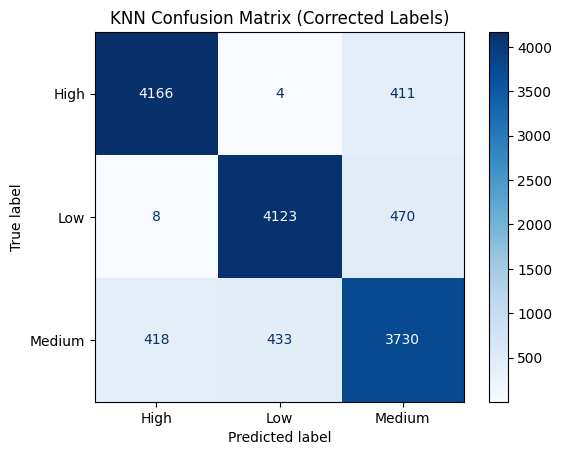

In [66]:
cm = confusion_matrix(y_test_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("KNN Confusion Matrix (Corrected Labels)")
plt.show()

### Additional plot 1: Residuals plot for MLR model
Important to diagnose the model and reveal whether your Linear Regression model has systematic errors. Ideally residuals should be randomly scattered around 0 without any patterns such as curve, funnel shape, line etc..

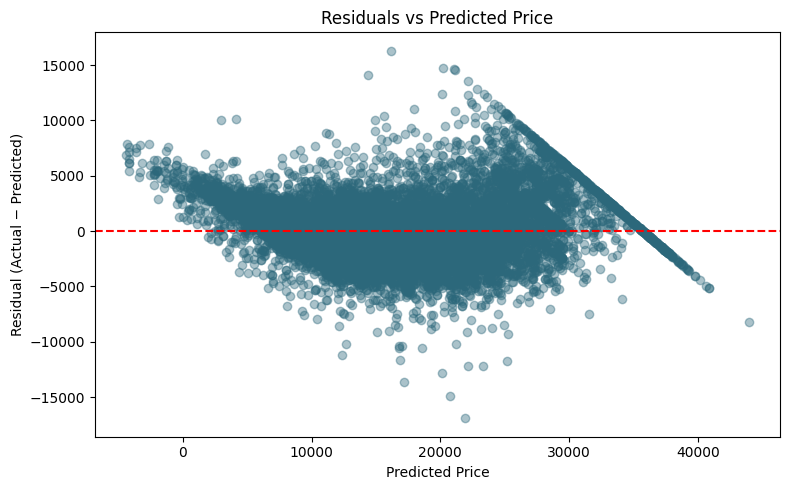

Mean Residual  : 50.64
Std  Residual  : 2600.75


In [70]:
residuals = y_test - multi_y_test_pred

plt.figure(figsize=(8, 5))
plt.scatter(multi_y_test_pred, residuals, alpha=0.4, color='#2C687B')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residuals vs Predicted Price')
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual − Predicted)')
plt.tight_layout()
plt.show()

print(f"Mean Residual  : {residuals.mean():.2f}")
print(f"Std  Residual  : {residuals.std():.2f}")

### Observations:
*Mean Residual = 50.64 (very close to 0), This means the model is unbiased.\
*The fan shape at the start: this likely means that the model is more accurate for cheap cars than for expensive cars.\
*The Diagonal Line on the Right: This is due to clipping for outliers. The model is still trying to predict higher values for these outliers.\
*The slight U-shape: This slight curve suggests that the relationship between the features and price isn't perfectly linear

### Additional Plot 2: Boxplot Brand vs Price 
The reason is to explore the distribution of the price for different brands

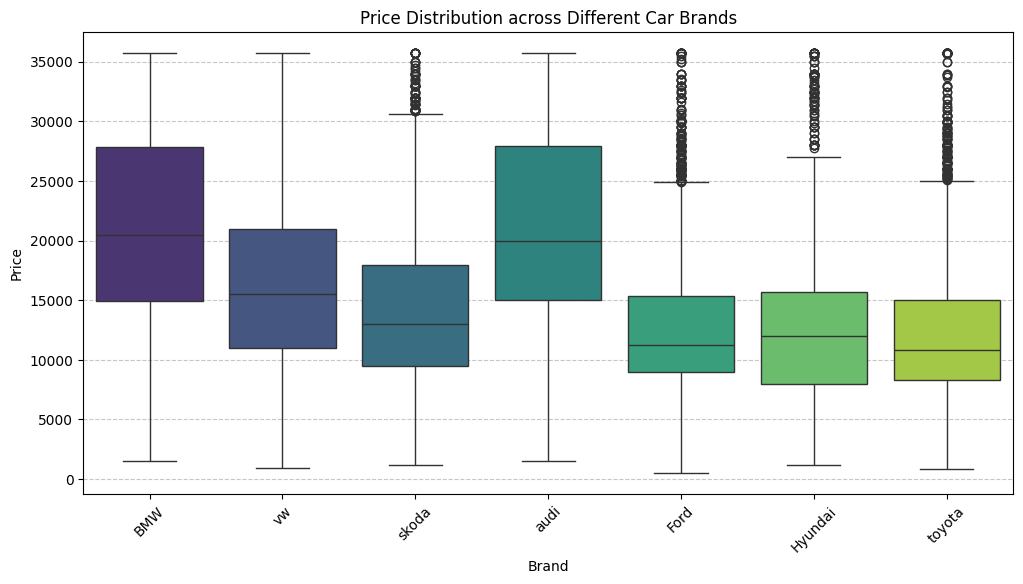

In [73]:
X_train_temp = X_train.copy()
X_train_temp['Price'] = y_train.values

plt.figure(figsize=(12, 6))
sns.boxplot(data=X_train_temp, x='Brand', y='Price',hue='Brand', palette='viridis', legend=False)
plt.xticks(rotation=45)
plt.title("Price Distribution across Different Car Brands")
plt.xlabel("Brand")
plt.ylabel("Price")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Observations:
Brands such as BMW and Audi have a higher price on average due to them being luxury cars.\
Skoda, Ford, Hyundai, and Toyota show many outliers above their upper whiskers.